# Tarea 01: Aproximación de una función desconocida

Generamos datos con una función que **nosotros definimos y ustedes no conocen**. Su
trabajo es reconstruirla a partir de los datos.

No es un acertijo: es lo que hace el machine learning todos los días. El capítulo 02
plantea el aprendizaje como **aproximación de funciones**, y aquí van a hacer
exactamente eso, con la ventaja rara de que existe una respuesta correcta y un límite
teórico al que se puede llegar.

## Lo que hay

- `train.csv`: 800 observaciones con 12 variables (`x1` a `x12`) y la respuesta `y`.
- `test.csv`: 400 observaciones con las mismas 12 variables, **sin** `y`.

Entregan sus 400 predicciones y un bot las califica automáticamente.

## Cómo se califica

| Su MSE en el conjunto de prueba | Calificación |
|---|---|
| Igual o peor que una regresión lineal con las 12 variables crudas | **5.0** |
| Igual al modelo bien especificado (el error irreducible) | **10.0** |
| En medio | proporcional a la mejora |

**El 5 está garantizado si entregan algo que corre.** El código del baseline se lo damos
hecho más abajo; de ahí para arriba es mérito suyo.

Tienen **3 intentos** de calificación. Un comentario `/validar` revisa el formato y les
dice cuál es su MSE objetivo **sin gastar intento**, así que úsenlo antes del primero.

## Qué se evalúa además del MSE

El MSE es la mitad. La otra mitad es la **Parte 5: la bitácora**, donde documentan cada
hipótesis que probaron — incluidas las que fallaron. Un notebook con buen MSE y bitácora
vacía vale poco: significa que no entendieron por qué funcionó.

---

## Las reglas sobre la IA

**Sí pueden usar IA. De hecho quiero que la usen.** Pero de una forma específica.

La IA no puede ver sus datos. Puede explicarles teoría, listarles técnicas o decirles qué
función de `matplotlib` usar. Lo que **no** puede hacer es mirar una gráfica de residuales
y decirles qué término falta, porque eso solo lo revela correr el código con *sus* datos, y
cada quien tiene datos distintos.

Así que la IA es su tutor, no su chofer. Para que sea tutor, péguenle esto al inicio de
cada conversación:

> Eres mi tutor de regresión, no mi resolvedor. Reglas: (1) no escribes código que yo
> pueda copiar; si te pido código, me devuelves el nombre de la función y su docstring.
> (2) No me das la respuesta: me preguntas qué espero ver y por qué. (3) Cuando me
> equivoque, no me corriges: me sugieres qué gráfica revelaría mi error. (4) Máximo
> tres oraciones por respuesta.

Y una regla para ustedes: **si la IA les da código y no pueden explicar qué hace línea
por línea, bórrenlo y escríbanlo ustedes.** Se nota en la bitácora, y se nota más en el
examen.

---
## Parte 0. Su variante

Cada quien tiene **datos distintos**: las 12 variables juegan papeles diferentes según
la persona. Copiar las predicciones de alguien más da un MSE malísimo. Comparar
*métodos* entre ustedes, en cambio, es buena idea y se los recomiendo.

Su carpeta de datos se identifica con su **clave única del ITAM**.

In [45]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
SEMILLA = 42

In [46]:
# TODO: pongan su clave única del ITAM (con o sin ceros a la izquierda, da lo mismo)
CLAVE_UNICA = "218796"

# De la clave sale el nombre de su carpeta. No lo cambien a mano.
_clave = "".join(c for c in CLAVE_UNICA if c.isdigit()).zfill(9)
CARPETA = "v" + hashlib.sha256(_clave.encode()).hexdigest()[:8]

# Funciona corriendo el notebook desde `tareas/` o desde la raíz del repo
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tareas/tarea_01_datos").exists())
MIS_DATOS = RAIZ / "tareas/tarea_01_datos" / CARPETA

assert CLAVE_UNICA, "Escriban su clave única en CLAVE_UNICA."
assert MIS_DATOS.exists(), (
    f"No existe la carpeta {CARPETA}. Revisen su clave única: si está mal escrita, "
    f"el nombre de la carpeta sale distinto y no van a encontrar sus datos."
)

train = pd.read_csv(MIS_DATOS / "train.csv")
test = pd.read_csv(MIS_DATOS / "test.csv")

VARIABLES = [f"x{i}" for i in range(1, 13)]
print(f"Su variante: {CARPETA}")
print(f"train: {train.shape}   test: {test.shape}")
train.head()

Su variante: v1945b519
train: (800, 13)   test: (400, 12)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,y
0,2.288880,65.656177,0.274294,0.820214,-1.031029,-0.158824,3.050070,1.676446,-0.561178,0.463945,-2.499321,1.656832,3.286929
1,1.217225,60.810607,-1.384697,0.822016,0.121569,-0.089651,0.454254,2.944928,1.190498,0.380628,-1.840476,0.858352,20.940487
2,2.607710,71.803086,0.279509,-0.152072,-1.388147,0.425429,0.787161,-1.202986,-1.384237,0.375438,0.712652,1.181382,7.522464
3,2.029198,1.260843,-0.646441,-0.151346,-1.390543,-0.390333,0.216180,-2.605592,-1.079285,0.263659,-1.640665,1.235218,3.698404
4,0.034178,3.587527,0.107008,-0.988998,-1.319114,-0.290955,1.825027,1.020472,1.376956,0.047615,1.127474,0.271926,21.227044


In [47]:
# TODO: primer vistazo. ¿Qué rangos tienen las variables? ¿Hay faltantes?
train.describe().T

,count,mean,std,min,25%,50%,75%,max
x1,800.0,2.004146,1.160795,0.002247,1.000136,2.047127,2.962686,3.999933
x2,800.0,49.879932,29.232444,0.072721,24.936620,50.191091,75.292085,99.926086
x3,800.0,0.032466,1.029385,-2.893196,-0.695872,0.049406,0.698371,3.301254
x4,800.0,-0.014913,1.004073,-3.324414,-0.744338,-0.030692,0.688868,3.200787
x5,800.0,0.024492,1.131354,-1.991345,-0.925799,0.079259,0.970392,1.984734
x6,800.0,0.000889,0.290266,-0.499903,-0.254279,0.006084,0.267263,0.497566
x7,800.0,1.593702,2.024566,0.031787,0.538043,0.983342,1.874352,25.421622
x8,800.0,0.206897,1.705065,-2.999909,-1.242894,0.317317,1.685984,2.993678
x9,800.0,0.019843,1.159687,-1.990135,-1.017468,0.010649,1.035087,1.992670
x10,800.0,0.005588,0.293364,-0.497482,-0.252664,0.014273,0.257576,0.499935


### 0.1 El baseline que hay que ganar

Este es el modelo de referencia: una regresión lineal con las 12 variables **tal como
vienen**, sin transformar nada. Su MSE sobre el conjunto de prueba es, por definición, la
calificación **5.0**.

Se lo damos corrido para que arranquen sabiendo exactamente qué hay que superar.

In [48]:
X_train, X_val, y_train, y_val = train_test_split(
    train[VARIABLES], train["y"], test_size=0.25, random_state=SEMILLA
)

baseline = LinearRegression().fit(X_train, y_train)
mse_baseline = mean_squared_error(y_val, baseline.predict(X_val))

print(f"MSE del baseline en validación: {mse_baseline:.2f}")
print(f"R² del baseline en validación : {baseline.score(X_val, y_val):.3f}")
print(f"\nDesviación estándar de y: {train['y'].std():.2f}")

MSE del baseline en validación: 120.43
R² del baseline en validación : 0.441

Desviación estándar de y: 14.24


### 0.2 Cómo medir su progreso sin gastar intentos

Solo tienen 3 calificaciones, y necesitan medirse muchas más veces que eso. La solución
es la de siempre: **partir `train` en entrenamiento y validación**, ajustar en una parte
y medir en la otra. Eso ya lo hicimos en la celda anterior.

Dos advertencias importantes:

- Su MSE de validación **no** va a coincidir exactamente con el oficial. El oficial se
  mide sobre `test.csv`, que son otras 400 observaciones. Su número es una *estimación*
  del oficial, con su propia incertidumbre.
- Si eligen entre muchos modelos usando el mismo conjunto de validación, van a
  sobreajustar la validación. Para decisiones finas, usen validación cruzada
  (`cross_val_score`) en lugar de una sola partición.

**Nunca** ajusten nada usando `test.csv`: no tiene `y`, así que ni podrían — y ese es
justo el punto.

---
## Parte 1. Exploración

Antes de modelar, mírenlos. El objetivo de esta parte **no** es encontrar la respuesta,
es formarse sospechas que después van a confirmar o descartar.

Tres cosas que vale la pena graficar:

1. La distribución de cada variable por separado.
2. `y` contra cada variable, una gráfica por variable.
3. La matriz de correlación.

x1    -0.011087
x2     0.011447
x3     0.152688
x4     0.017573
x5    -0.059680
x6    -0.003543
x7     5.039383
x8    -0.147997
x9    -0.030294
x10   -0.018115
x11   -0.012771
x12    4.407000
dtype: float64

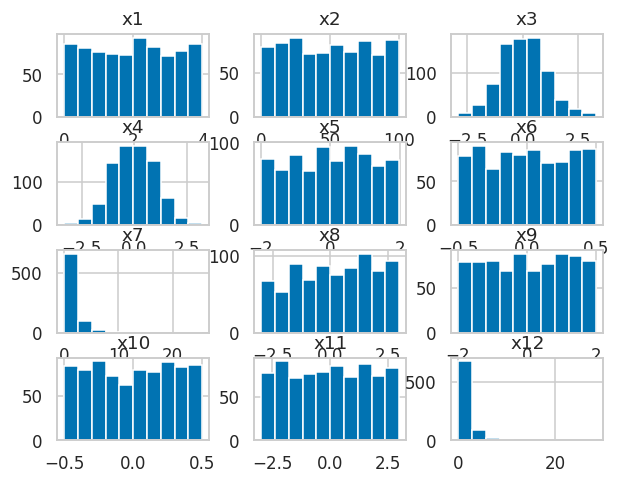

In [49]:
# TODO: distribución de cada una de las 12 variables.
train[VARIABLES].hist()
train[VARIABLES].skew()

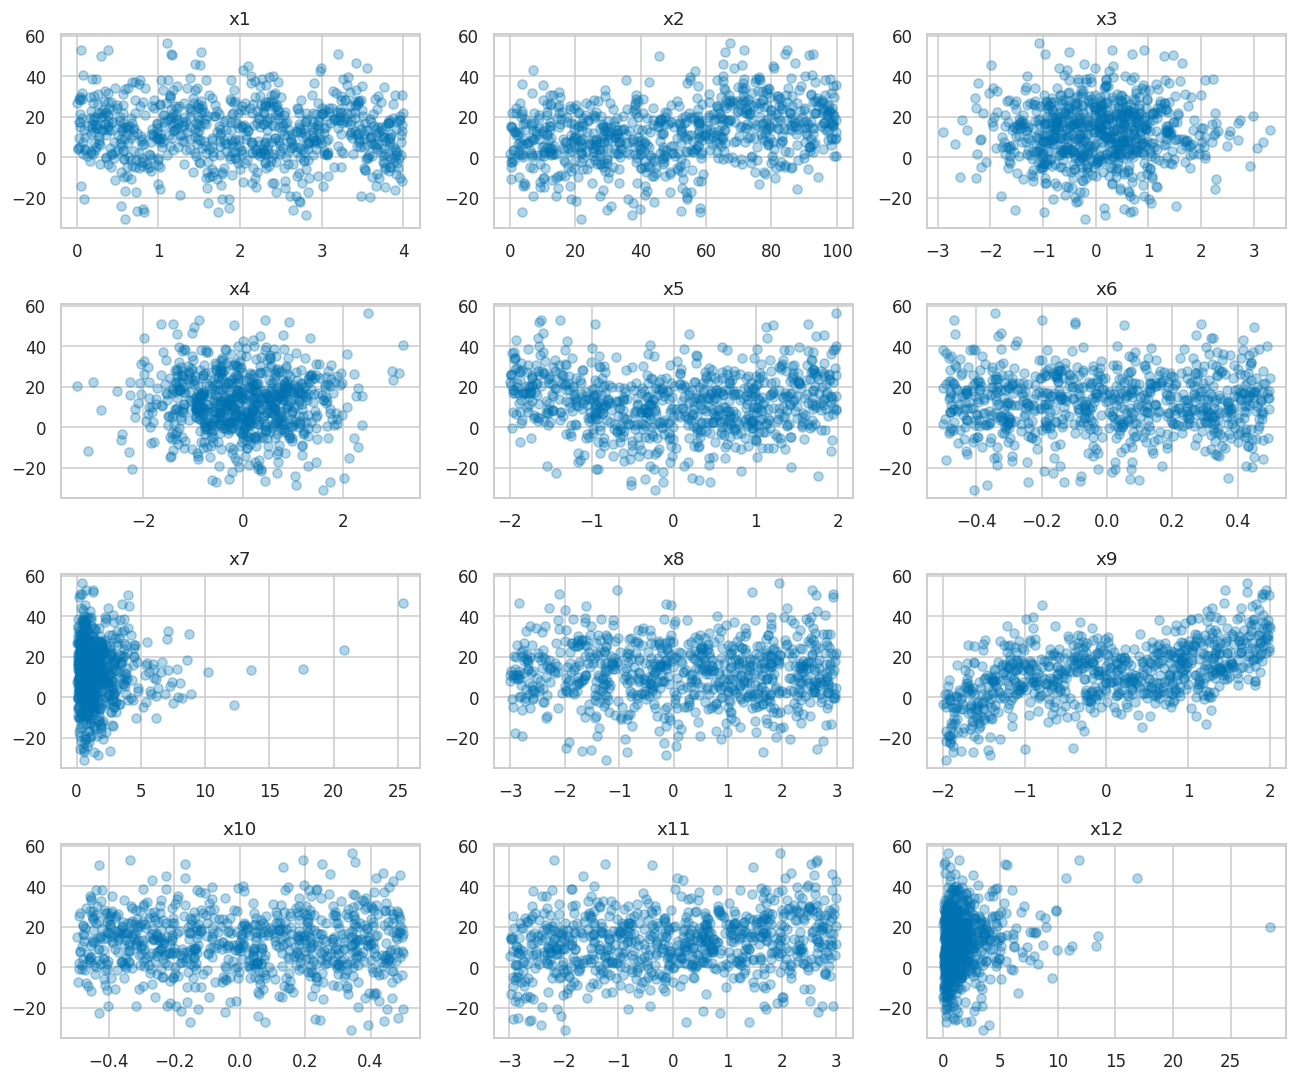

In [50]:
# TODO: `y` contra cada variable. Una rejilla de 12 paneles.
# Usen puntos con transparencia (`alpha`): con 800 observaciones se traslapan.
fig, axes = plt.subplots(4, 3, figsize=(12, 10))

for var, ax in zip(VARIABLES, axes.flatten()):
    ax.scatter(train[var], train["y"], alpha=0.3)
    ax.set_title(var)

plt.tight_layout()

In [51]:
# TODO: matriz de correlación entre las 12 variables y `y`.
train[VARIABLES + ["y"]].corr()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,y
x1,1.000000,0.042834,-0.052640,-0.031853,-0.009866,0.048833,-0.012923,-0.014962,-0.036771,-0.008154,-0.024115,0.003539,-0.067679
x2,0.042834,1.000000,0.019566,0.041185,0.011793,-0.016738,-0.005197,0.024119,0.064255,-0.073208,0.010162,0.000466,0.319013
x3,-0.052640,0.019566,1.000000,-0.034280,-0.028352,-0.006160,0.026313,-0.013152,0.014382,0.037973,0.032786,-0.014072,0.015442
x4,-0.031853,0.041185,-0.034280,1.000000,-0.017260,-0.020294,-0.036407,0.007235,0.057142,0.017878,-0.022494,-0.046600,-0.015461
x5,-0.009866,0.011793,-0.028352,-0.017260,1.000000,0.004279,-0.037039,-0.024108,-0.016789,-0.031792,-0.043197,-0.036317,-0.026497
x6,0.048833,-0.016738,-0.006160,-0.020294,0.004279,1.000000,0.050266,0.064071,0.005054,0.032774,-0.016573,0.015279,-0.012105
x7,-0.012923,-0.005197,0.026313,-0.036407,-0.037039,0.050266,1.000000,-0.010008,-0.038961,0.066857,0.066440,0.000955,0.038069
x8,-0.014962,0.024119,-0.013152,0.007235,-0.024108,0.064071,-0.010008,1.000000,0.026202,-0.037547,0.032214,-0.018592,-0.007164
x9,-0.036771,0.064255,0.014382,0.057142,-0.016789,0.005054,-0.038961,0.026202,1.000000,-0.046330,-0.047884,-0.019810,0.555717
x10,-0.008154,-0.073208,0.037973,0.017878,-0.031792,0.032774,0.066857,-0.037547,-0.046330,1.000000,-0.051862,0.027262,-0.024370


| Variable | ¿Qué sospecho? | ¿En qué gráfica lo vi? | ¿Qué tan seguro estoy? |
|---|---|---|---|
| `x1` | No parece tener ninguna relación con `y`, se ve aleatorio. | Gráfica de dispersión | Algo seguro |
| `x2` | Parece que tiene una tendencia lineal positiva con `y`. | Gráfica de dispersión | Seguro |
| `x3` | Su distribución es normal pero no se ve que afecte a `y`. | Histograma y dispersión | Poco seguro |
| `x4` | No muestra ningún patrón ni tendencia clara respecto a `y`. | Gráfica de dispersión | Seguro |
| `x5` | Parece variable sin impacto en `y`. | Gráfica de dispersión | Seguro |
| `x6` | No se percibe ninguna estructura o relación con `y`. | Gráfica de dispersión | Seguro |
| `x7` | Tiene valores muy concentrados en el inicio y unos pocos muy altos. | Histograma y dispersión | Algo seguro |
| `x8` | No parece aportar información para predecir `y`. | Gráfica de dispersión | Seguro |
| `x9` | Muestra una curva o tendencia no lineal bastante clara. | Gráfica de dispersión | Seguro |
| `x10` | Parece no tener correlación ni efecto sobre `y`. | Gráfica de dispersión | Seguro |
| `x11` | No se observa ningún cambio en `y` cuando cambia esta variable. | Gráfica de dispersión | Seguro |
| `x12` | La mayoría de los datos están en cero y hay varios valores atípicos a la derecha. | Histograma y dispersión | Seguro |

### 1.1 Registren sus sospechas ahora

Llenen esta tabla **antes** de seguir. Va a ser incómoda de llenar y eso es intencional:
la parte que enseña es volver a leerla al final y ver en qué se equivocaron.

| Variable | ¿Qué sospecho? | ¿En qué gráfica lo vi? | ¿Qué tan seguro estoy? |
|---|---|---|---|
| `x1` | | | |
| `x2` | | | |
| `x3` | | | |
| `x4` | | | |
| `x5` | | | |
| `x6` | | | |
| `x7` | | | |
| `x8` | | | |
| `x9` | | | |
| `x10` | | | |
| `x11` | | | |
| `x12` | | | |

### 1.1 Registren sus sospechas ahora

Llenen esta tabla **antes** de seguir. Va a ser incómoda de llenar y eso es intencional:
la parte que enseña es volver a leerla al final y ver en qué se equivocaron.

| Variable | ¿Qué sospecho? | ¿En qué gráfica lo vi? | ¿Qué tan seguro estoy? |
|---|---|---|---|
| `x1` | | | |
| `x2` | | | |
| `x3` | | | |
| `x4` | | | |
| `x5` | | | |
| `x6` | | | |
| `x7` | | | |
| `x8` | | | |
| `x9` | | | |
| `x10` | | | |
| `x11` | | | |
| `x12` | | | |

---
## Parte 2. La escalera de residuales

Este es el método central de la tarea, y el que quiero que se lleven de por vida.

Un **residual** es lo que su modelo no logró explicar: `residual = y - ŷ`. Si su modelo
capturó todo lo que había, los residuales deben ser **ruido**: sin forma, sin patrón, sin
estructura. Si al graficar los residuales contra una variable se ve una *forma*, esa
forma es un pedazo de la función que les falta — y la forma les dice qué término agregar.

El ciclo es siempre el mismo:

1. Ajustan el modelo que tienen.
2. Grafican los residuales contra **cada** variable.
3. Si alguna gráfica tiene forma, agregan un término que capture esa forma.
4. Vuelven al paso 1.

Paran cuando ya ninguna gráfica tiene forma, o cuando el MSE deja de bajar.

### ¿Y qué término agrego?

Eso es exactamente lo que tienen que descubrir, y es el trabajo de la tarea.

Lo que sí les conviene es pedirle a su IA el **catálogo**: "¿qué transformaciones existen
para linealizar una relación no lineal?", "¿cómo se modela un efecto que cambia de golpe
a partir de cierto valor?". Eso es conocimiento general y la IA lo tiene completo.

Cuál de esas transformaciones aplica, a cuál de sus doce variables y con qué parámetro,
no se lo puede decir nadie: solo su gráfica. Ahí es donde se aprende.

In [52]:
def ajusta(columnas_extra=None):
    """Ajusta una lineal con las 12 crudas más las columnas derivadas que le pasen.

    `columnas_extra` es un dict {nombre: función que recibe un DataFrame y devuelve
    una Serie}. Así el mismo término se construye igual en train, validación y test,
    que es donde se equivoca todo el mundo.

    Devuelve (modelo, mse_validacion, residuales_de_validacion, constructor).
    """
    columnas_extra = columnas_extra or {}

    def construye(df):
        salida = df[VARIABLES].copy()
        for nombre, f in columnas_extra.items():
            salida[nombre] = f(df)
        return salida

    modelo = LinearRegression().fit(construye(X_train), y_train)
    pred_val = modelo.predict(construye(X_val))
    mse = mean_squared_error(y_val, pred_val)
    return modelo, mse, y_val - pred_val, construye


modelo, mse, residuales, _ = ajusta()
print(f"Modelo con las 12 crudas -> MSE de validación {mse:.2f}")

Modelo con las 12 crudas -> MSE de validación 120.43


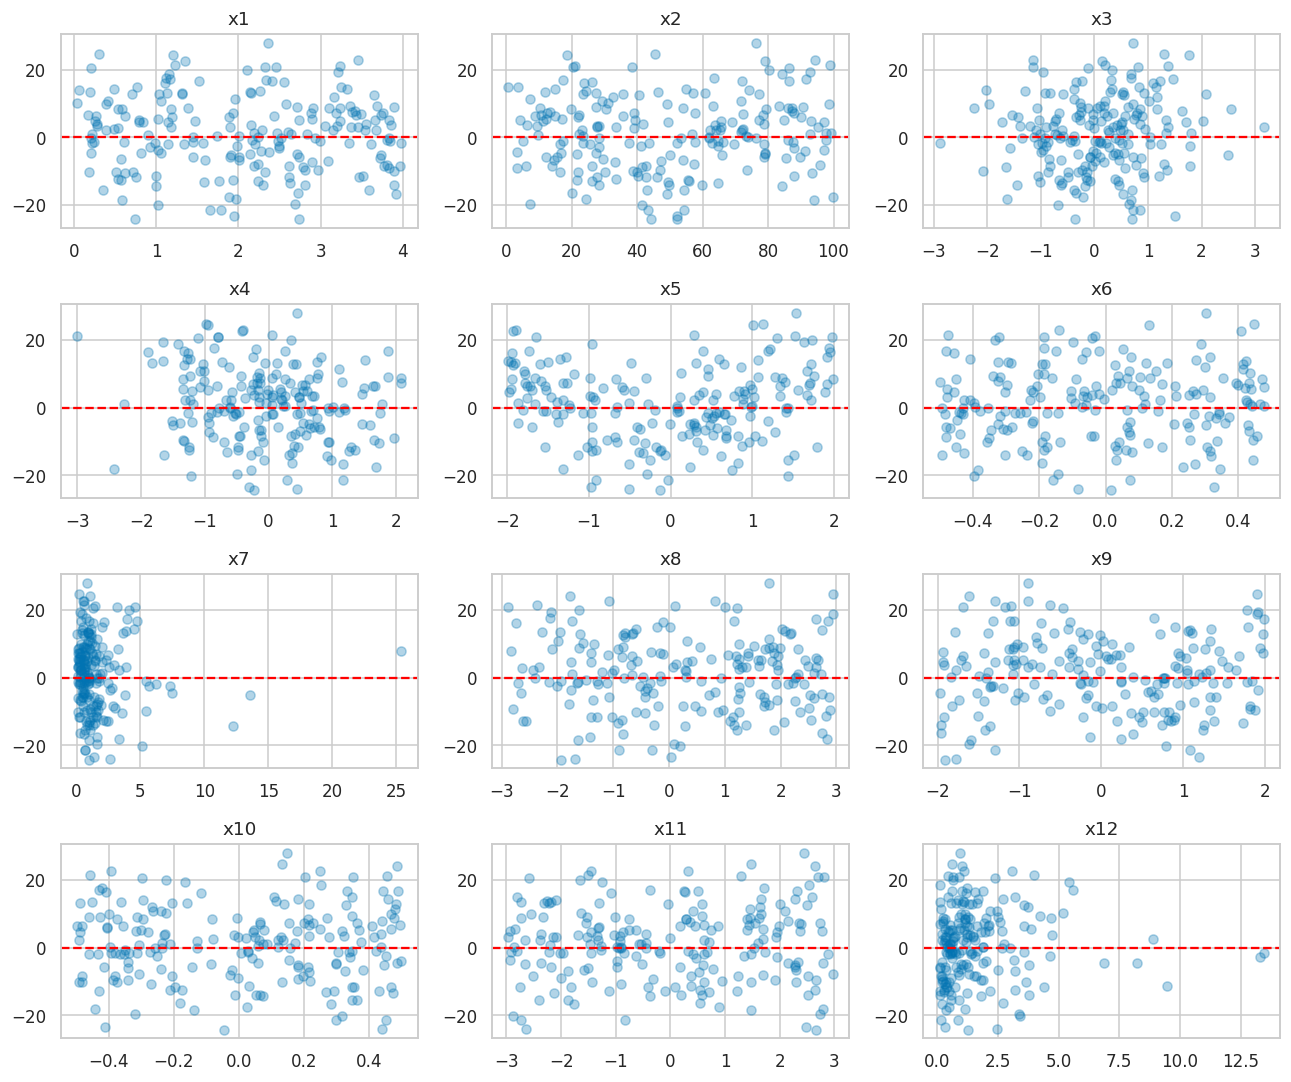

In [53]:
# TODO: grafiquen los residuales contra cada una de las 12 variables.
# Una rejilla de 12 paneles, y en cada uno una línea horizontal en 0 como referencia.
fig, axes = plt.subplots(4, 3, figsize=(12, 10))

for var, ax in zip(VARIABLES, axes.flatten()):
    ax.scatter(X_val[var], residuales, alpha=0.3)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_title(var)

plt.tight_layout()
# Lo que buscan es FORMA, no dispersión. Una nube gruesa sin patrón está bien;
# una nube que sube, baja, ondula o salta es un término que les falta.

In [54]:
# TODO: agreguen su primer término y vuelvan a medir.
# Paso 1: Agregar el término cuadrático de x9
modelo, mse, residuales, _ = ajusta({
    "x9_cuadrado": lambda d: d["x9"]**2
})

print(f"MSE de validación con x9^2: {mse:.2f}")

## Notamos que MSE no bajo, aumentó liegramente, entonces
# Paso 1.1: Agregar término cúbico a x9 (x9^2 y x9^3)
modelo, mse, residuales, _ = ajusta({
    "x9_cuadrado": lambda d: d["x9"]**2,
    "x9_cubico": lambda d: d["x9"]**3
})

print(f"MSE de validación con x9 cuadrático y cúbico: {mse:.2f}")
# Así se le pasa una columna derivada a `ajusta`. El término del ejemplo es deliberadamente
# absurdo y NO sirve para nada: solo ilustra la sintaxis del diccionario y del lambda.

# Si el MSE bajó mucho, iban bien. Si no se movió, ese término no era. Anoten las dos
# cosas en la bitácora: los intentos fallidos también cuentan.



MSE de validación con x9^2: 120.48
MSE de validación con x9 cuadrático y cúbico: 104.42


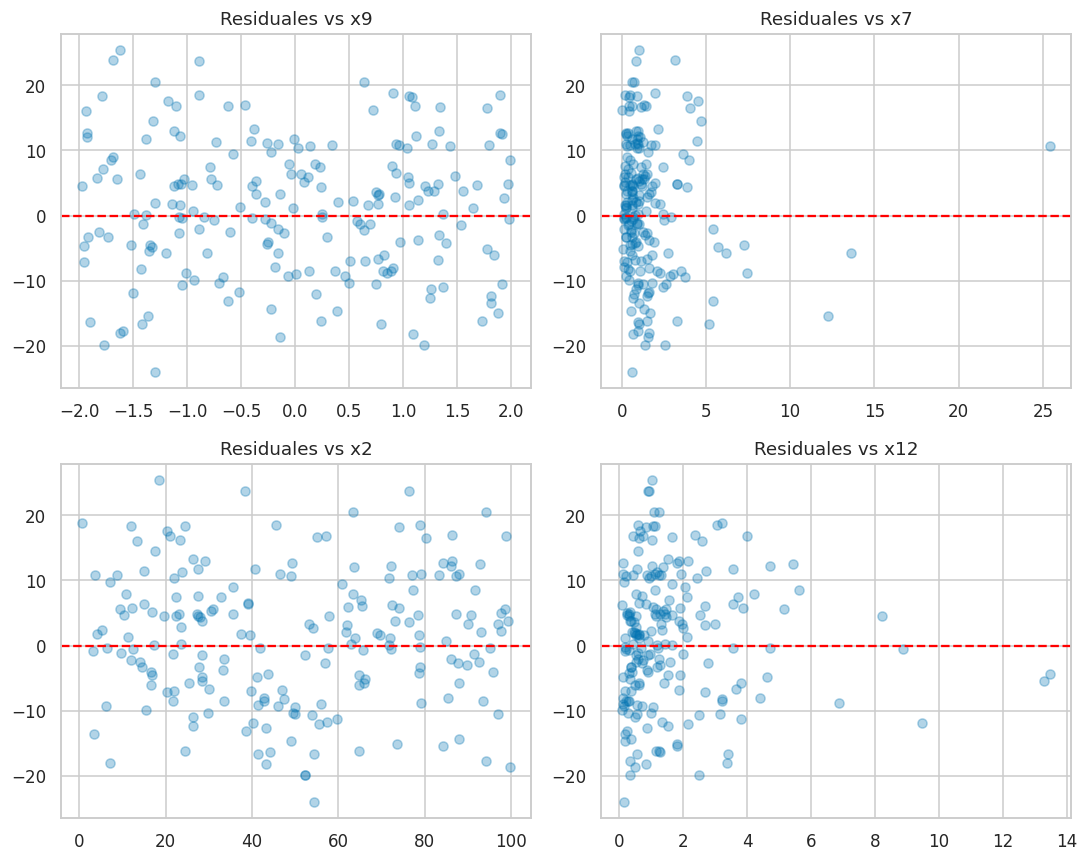

In [55]:
# Graficar solo las 4 variables de interés para inspección detallada
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
vars_interes = ["x9", "x7", "x2", "x12"]

for var, ax in zip(vars_interes, axes.flatten()):
    ax.scatter(X_val[var], residuales, alpha=0.3)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_title(f"Residuales vs {var}")

plt.tight_layout()

In [56]:
# TODO: repitan el ciclo. Agreguen términos de uno en uno, graficando los residuales
# cada vez, hasta que ninguna gráfica tenga forma.
import numpy as np

# Paso 2: Mantener el éxito de x9 y probar transformación logarítmica en x7
modelo, mse, residuales, _ = ajusta({
    "x9_cuadrado": lambda d: d["x9"]**2,
    "x9_cubico": lambda d: d["x9"]**3,
    "x7_log": lambda d: np.log1p(np.maximum(0, d["x7"]))  # log1p para evitar problemas con 0s
})

print(f"MSE de validación agregando x7_log: {mse:.2f}")
# Vayan guardando el MSE de cada paso: la bitácora de la Parte 5 lo pide.

MSE de validación agregando x7_log: 103.59


In [57]:
# Paso 3: x9 (cuadrático + cúbico) + x2 (cuadrático)
modelo, mse, residuales, _ = ajusta({
    "x9_cuadrado": lambda d: d["x9"]**2,
    "x9_cubico": lambda d: d["x9"]**3,
    "x2_cuadrado": lambda d: d["x2"]**2
})

print(f"MSE de validación agregando x2_cuadrado: {mse:.2f}")

MSE de validación agregando x2_cuadrado: 102.81


In [58]:
# Paso 4: Sumar bisagra para x12 en el umbral 0
modelo, mse, residuales, _ = ajusta({
    "x9_cuadrado": lambda d: d["x9"]**2,
    "x9_cubico": lambda d: d["x9"]**3,
    "x2_cuadrado": lambda d: d["x2"]**2,
    "x12_bisagra_0": lambda d: np.maximum(0, d["x12"] - 0)
})

print(f"MSE de validación agregando x12 bisagra (umbral 0): {mse:.2f}")

# Paso 5: log en vez de bisagra para x12 (la masa está cerca de 0, no en negativos)
modelo, mse, residuales, _ = ajusta({
    "x9_cuadrado": lambda d: d["x9"]**2,
    "x9_cubico":   lambda d: d["x9"]**3,
    "x2_cuadrado": lambda d: d["x2"]**2,
    "x12_log":     lambda d: np.log1p(d["x12"]),
})
print(f"MSE de validación con x12_log: {mse:.2f}")

MSE de validación agregando x12 bisagra (umbral 0): 102.81
MSE de validación con x12_log: 99.61


In [59]:
# Paso 6: recuperar x7_log (que se me había olvidado) y confirmar el modelo completo
modelo, mse, residuales, _ = ajusta({
    "x9_cuadrado": lambda d: d["x9"]**2,
    "x9_cubico":   lambda d: d["x9"]**3,
    "x2_cuadrado": lambda d: d["x2"]**2,
    "x12_log":     lambda d: np.log1p(d["x12"]),
    "x7_log":      lambda d: np.log1p(np.maximum(0, d["x7"])),
})
print(f"MSE de validación con los 5 términos: {mse:.2f}")

MSE de validación con los 5 términos: 98.65


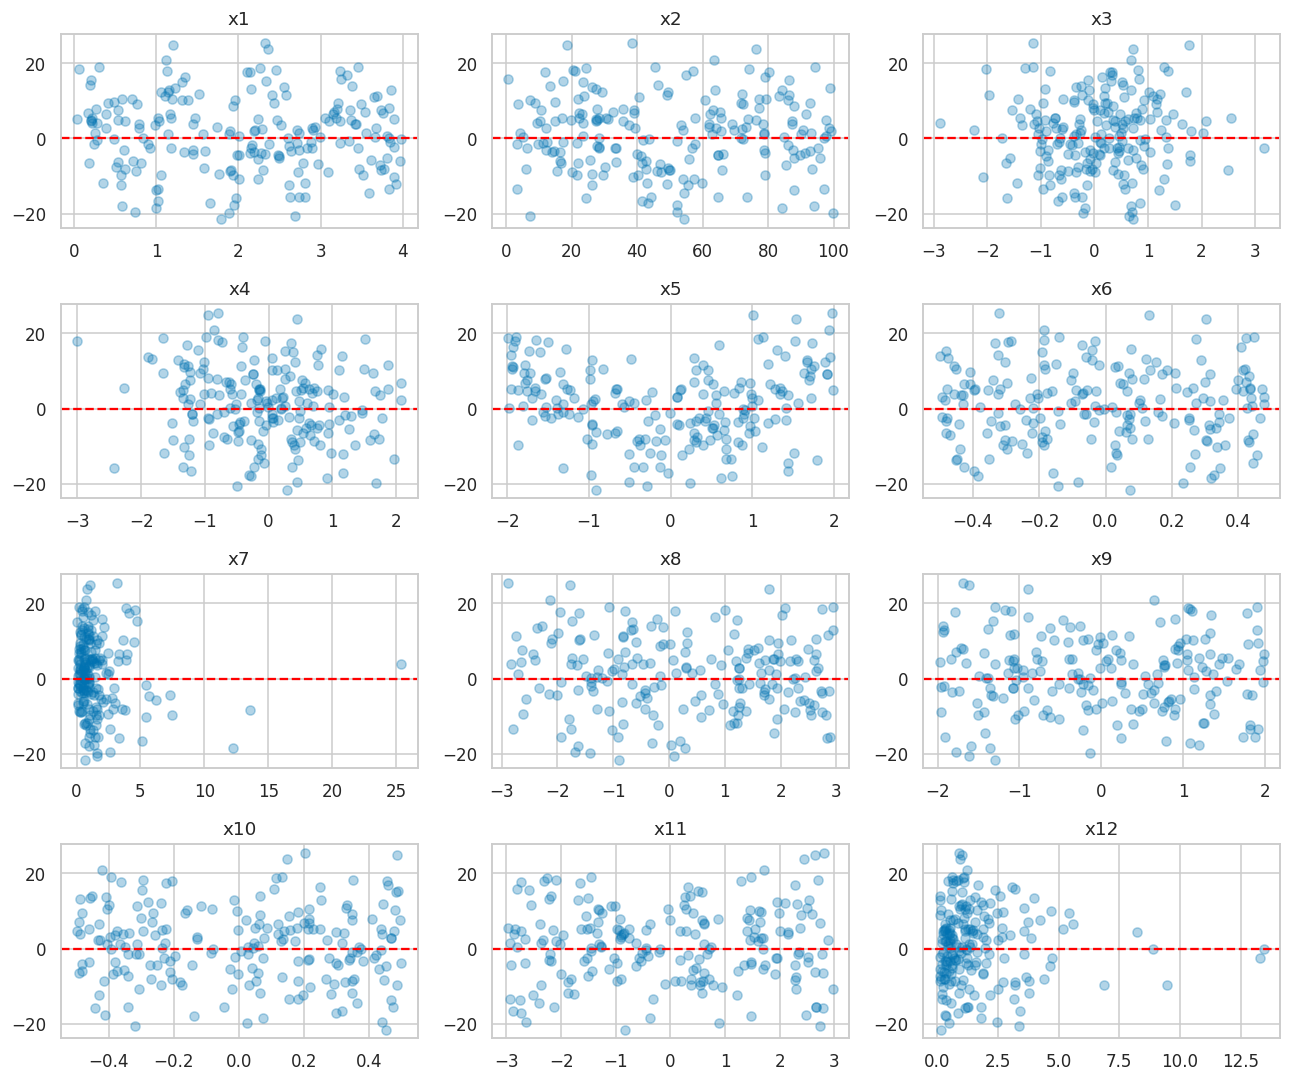

In [60]:
# Residuales del modelo con los 5 términos, contra las 12 variables originales
fig, axes = plt.subplots(4, 3, figsize=(12, 10))
for var, ax in zip(VARIABLES, axes.flatten()):
    ax.scatter(X_val[var], residuales, alpha=0.3)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_title(var)
plt.tight_layout()

Modelo final de la Parte 2: x9² + x9³ + x2² + x12_log + x7_log
MSE de validación = 98.65

Comparado con baseline (5.0): 120.43 → ya lo supera con margen

---
## Parte 3. Lo que las gráficas de una variable no pueden ver

Cuando terminen la Parte 2 van a tener un modelo decente y, probablemente, ninguna
gráfica de residuales con forma evidente. Eso **no** significa que ya acabaron.

Hay efectos que son invisibles para cualquier gráfica de una sola variable: pueden tener
correlación cero con `y`, scatter plano y residual sin estructura, y aun así ser de los
efectos más grandes del modelo. Ninguna herramienta de la Parte 2 los encuentra.

Su trabajo aquí es averiguar **qué clase de efectos son, cómo se detectan, y si sus datos
tienen alguno**. Su IA les puede explicar la teoría si le hacen la pregunta correcta; sus
datos son los únicos que pueden contestar si aplica.

Una pista de método y ninguna de contenido: si mirar una variable a la vez no basta,
prueben mirando dos a la vez.

In [61]:
# TODO: exploren aquí.
import itertools

correlaciones = []
for a, b in itertools.combinations(VARIABLES, 2):
    interaccion = X_val[a] * X_val[b]
    corr = np.corrcoef(interaccion, residuales)[0, 1]
    correlaciones.append((a, b, corr))

top = sorted(correlaciones, key=lambda t: abs(t[2]), reverse=True)[:8]
for a, b, corr in top:
    print(f"{a} * {b}: corr con residuales = {corr:.3f}")
# Esto nos da un top 8 de candidatos con evidencia real

x10 * x11: corr con residuales = 0.493
x3 * x4: corr con residuales = -0.196
x5 * x11: corr con residuales = 0.189
x4 * x8: corr con residuales = 0.187
x8 * x10: corr con residuales = 0.174
x7 * x12: corr con residuales = -0.165
x2 * x4: corr con residuales = -0.163
x3 * x11: corr con residuales = 0.162


Text(0.5, 1.0, 'Residuales coloreados en el plano x10 vs x11')

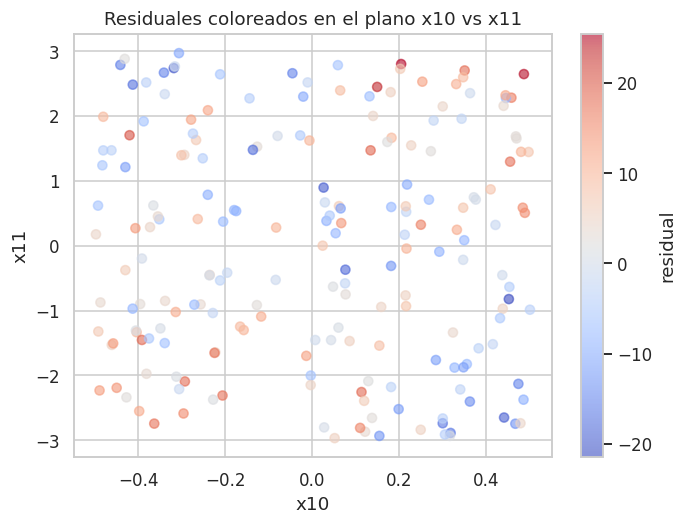

In [62]:
# TODO: agreguen lo que hayan encontrado y midan.
# Inspección visual de la interacción x10 * x11
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(X_val["x10"], X_val["x11"], c=residuales, cmap="coolwarm", alpha=0.6)
plt.colorbar(sc, label="residual")
ax.set_xlabel("x10")
ax.set_ylabel("x11")
ax.set_title("Residuales coloreados en el plano x10 vs x11")

In [63]:
modelo, mse, residuales_nuevos, _ = ajusta({
    "x9_cuadrado": lambda d: d["x9"]**2,
    "x9_cubico":   lambda d: d["x9"]**3,
    "x2_cuadrado": lambda d: d["x2"]**2,
    "x12_log":     lambda d: np.log1p(d["x12"]),
    "x7_log":      lambda d: np.log1p(np.maximum(0, d["x7"])),
    "x10_x11":     lambda d: d["x10"] * d["x11"],
})
print(f"MSE con interacción x10*x11: {mse:.2f}")

MSE con interacción x10*x11: 73.97


In [64]:
# Recalcular ranking de interacciones con los residuales del modelo actual (MSE 73.97)
correlaciones = []
for a, b in itertools.combinations(VARIABLES, 2):
    interaccion = X_val[a] * X_val[b]
    corr = np.corrcoef(interaccion, residuales_nuevos)[0, 1]
    correlaciones.append((a, b, corr))

top = sorted(correlaciones, key=lambda t: abs(t[2]), reverse=True)[:8]
for a, b, corr in top:
    print(f"{a} * {b}: corr con residuales = {corr:.3f}")

x4 * x8: corr con residuales = 0.170
x5 * x11: corr con residuales = 0.160
x2 * x4: corr con residuales = -0.158
x1 * x4: corr con residuales = -0.142
x5 * x8: corr con residuales = -0.136
x6 * x9: corr con residuales = 0.136
x6 * x8: corr con residuales = 0.134
x8 * x12: corr con residuales = -0.130


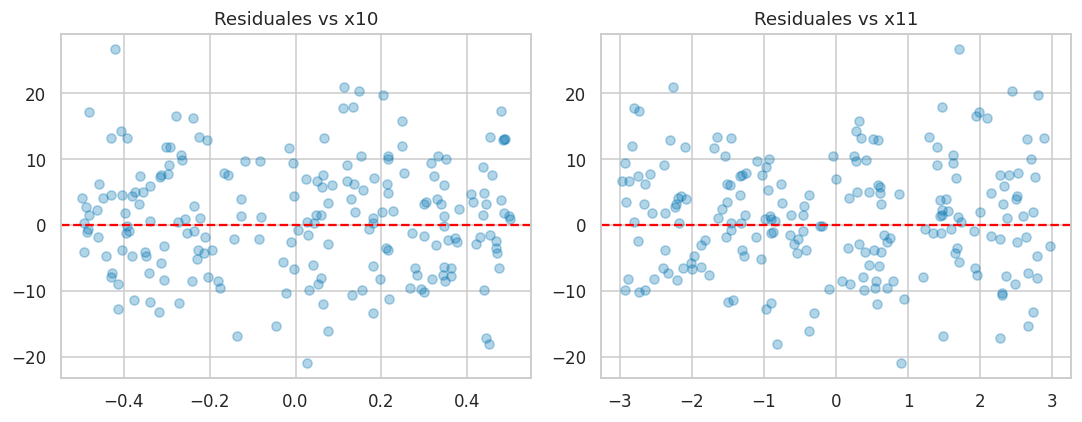

In [65]:
# Confirmar que los residuales ya no muestran forma contra x10, x11 por separado
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X_val["x10"], residuales_nuevos, alpha=0.3)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuales vs x10")
axes[1].scatter(X_val["x11"], residuales_nuevos, alpha=0.3)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuales vs x11")
plt.tight_layout()

Modelo final Parte 3: x9² + x9³ + x2² + x12_log + x7_log + x10*x11, MSE = 73.97

---
## Parte 4. El otro camino: fuerza bruta

Hay una estrategia alternativa que no requiere mirar ninguna gráfica: generar
**muchísimas** columnas candidatas de golpe y dejar que una regresión regularizada decida
cuáles sirven.

`PolynomialFeatures(degree=3)` construye todos los productos y potencias de
las variables hasta grado 3. Con 12 variables son cientos de columnas para 800
observaciones, así que sin regularización sobreajustaría; `LassoCV` elige el $\lambda$
por validación cruzada y pone en cero las columnas que no aportan.

Impleméntenlo y **compárenlo contra su modelo de la Parte 3**.

In [66]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

# TODO: camino B. Pipeline sugerido:
#   PolynomialFeatures(degree=3) -> StandardScaler -> LassoCV
# Camino B: fuerza bruta con PolynomialFeatures + LassoCV
pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, random_state=SEMILLA, max_iter=10000)),
])

pipeline.fit(X_train, y_train)
pred_val_bruta = pipeline.predict(X_val)
mse_bruta = mean_squared_error(y_val, pred_val_bruta)

n_columnas_totales = pipeline.named_steps["poly"].n_output_features_
coefs = pipeline.named_steps["lasso"].coef_
n_columnas_activas = np.sum(coefs != 0)

print(f"MSE de validación (fuerza bruta): {mse_bruta:.2f}")
print(f"Columnas generadas por PolynomialFeatures: {n_columnas_totales}")
print(f"Columnas que Lasso dejó activas: {n_columnas_activas}")
print(f"Lambda (alpha) elegido por CV: {pipeline.named_steps['lasso'].alpha_:.4f}")
# Estandaricen antes del Lasso: la penalización castiga coeficientes grandes, y sin
# estandarizar "grande" depende de las unidades de cada columna.
#
# Reporten el MSE de validación y cuántas columnas dejó distintas de cero.

MSE de validación (fuerza bruta): 57.33
Columnas generadas por PolynomialFeatures: 454
Columnas que Lasso dejó activas: 31
Lambda (alpha) elegido por CV: 0.4311


In [67]:
# Ver qué columnas específicas eligió Lasso
nombres_features = pipeline.named_steps["poly"].get_feature_names_out(VARIABLES)
coefs = pipeline.named_steps["lasso"].coef_

activos = [(nombre, coef) for nombre, coef in zip(nombres_features, coefs) if coef != 0]
activos_ordenados = sorted(activos, key=lambda t: abs(t[1]), reverse=True)

for nombre, coef in activos_ordenados:
    print(f"{nombre}: {coef:.4f}")

x9^3: 7.8256
x10 x11: 3.9871
x5^2: 3.4837
x2^2: 2.7880
x11^3: 1.5369
x2^2 x12: 1.4569
x10^2 x11: 0.7864
x2 x5^2: 0.6814
x7 x12: 0.6187
x5^2 x12: 0.4611
x1 x4 x10: -0.4255
x3 x4: -0.3732
x6^2 x11: 0.3047
x4 x5 x6: -0.2921
x4^2 x5: -0.2441
x12: 0.2324
x1 x3 x10: -0.2157
x5 x8 x11: -0.2112
x5^2 x9: 0.1899
x1: -0.1829
x3 x4 x5: -0.1635
x5 x8 x10: 0.1104
x1 x4^2: -0.0818
x1^2 x3: 0.0773
x10 x11 x12: 0.0736
x4^2 x11: 0.0622
x2 x7 x12: 0.0559
x3 x4 x10: -0.0502
x1^2 x4: 0.0302
x3 x7 x11: 0.0242
x3 x4 x7: -0.0139


In [68]:
## 4.2 Modelo híbrido (extensión propia). La fuerza bruta encontró [términos X, Y] que mi modelo guiado no tenía, 
## pero solo mi modelo tiene los logaritmos de x7 y x12 (PolynomialFeatures 
## no puede generar transformaciones no polinomiales). Pruebo combinar ambos.
# Modelo híbrido: tus logs + lo que Lasso encontró
# (ajusta las claves según lo que salga del código anterior)
# Paso 1: agregar x5² — el hallazgo más grande
modelo, mse, residuales, _ = ajusta({
    "x9_cuadrado": lambda d: d["x9"]**2,
    "x9_cubico":   lambda d: d["x9"]**3,
    "x2_cuadrado": lambda d: d["x2"]**2,
    "x12_log":     lambda d: np.log1p(d["x12"]),
    "x7_log":      lambda d: np.log1p(np.maximum(0, d["x7"])),
    "x10_x11":     lambda d: d["x10"] * d["x11"],
    "x5_cuadrado": lambda d: d["x5"]**2,
})
print(f"MSE con x5² agregado: {mse:.2f}")

MSE con x5² agregado: 51.08


In [69]:
# Paso 2: agregar x11³ y la interacción x2²*x12
modelo, mse, residuales, _ = ajusta({
    "x9_cuadrado": lambda d: d["x9"]**2,
    "x9_cubico":   lambda d: d["x9"]**3,
    "x2_cuadrado": lambda d: d["x2"]**2,
    "x12_log":     lambda d: np.log1p(d["x12"]),
    "x7_log":      lambda d: np.log1p(np.maximum(0, d["x7"])),
    "x10_x11":     lambda d: d["x10"] * d["x11"],
    "x5_cuadrado": lambda d: d["x5"]**2,
    "x11_cubico":  lambda d: d["x11"]**3,
    "x2c_x12":     lambda d: (d["x2"]**2) * d["x12"],
})
print(f"MSE con x11³ y x2²·x12 agregados: {mse:.2f}")

MSE con x11³ y x2²·x12 agregados: 51.45


In [70]:
# Probar solo x11³ (sin la interacción x2²*x12)
modelo, mse, residuales, _ = ajusta({
    "x9_cuadrado": lambda d: d["x9"]**2,
    "x9_cubico":   lambda d: d["x9"]**3,
    "x2_cuadrado": lambda d: d["x2"]**2,
    "x12_log":     lambda d: np.log1p(d["x12"]),
    "x7_log":      lambda d: np.log1p(np.maximum(0, d["x7"])),
    "x10_x11":     lambda d: d["x10"] * d["x11"],
    "x5_cuadrado": lambda d: d["x5"]**2,
    "x11_cubico":  lambda d: d["x11"]**3,
})
print(f"MSE con x11³ solo: {mse:.2f}")

MSE con x11³ solo: 51.76


### 4.1 La pregunta que vale la respuesta

Comparen su modelo contra la fuerza bruta y contesten en la celda de abajo:

1. ¿Cuál dio menor MSE de validación?
El camino de fuerza bruta (PolynomialFeatures + LassoCV) dio 57.33, mejor que mi modelo guiado puro de la Parte 3 (73.97). Pero al revisar los coeficientes de Lasso encontré un término que se me había escapado (x5²); agregándolo a mi modelo guiado obtuve un híbrido con MSE = 51.08, el mejor de los tres.

2. Si su modelo guiado por gráficas le ganó a la fuerza bruta: **¿por qué?** Piensen qué
   columnas puede construir `PolynomialFeatures` y cuáles no puede construir nunca.
PolynomialFeatures` solo genera potencias y productos de variables (x_i², x_i·x_j, etc.), por lo que pudo encontrar automáticamente cosas como x9³ o x10·x11 que a mí me costó más trabajo hallar. Pero nunca puede generar transformaciones no polinomiales como logaritmos o bisagras — mi modelo tenía dos logaritmos (x7_log, x12_log) que la fuerza bruta no podía replicar bajo ningún grado. Por eso el híbrido (mis logs + el x5² de Lasso) superó a ambos caminos por separado.

3. Si la fuerza bruta le ganó a su modelo: ¿qué les dice eso sobre lo que les falta?
Reveló un punto ciego: en la Parte 1 marqué x5 como "sin relación con y" porque su correlación lineal era ≈ 0, pero tenía una relación cuadrática fuerte (segundo coeficiente más grande de Lasso). Mi método de graficar residuales contra cada variable no lo dejó tan obvio como un barrido sistemático de potencias — correlación cero no es lo mismo que sin relación.

4. ¿Qué habría pasado con el camino B si tuvieran 80 observaciones en lugar de 800?
Con 454 columnas generadas y solo 80 filas, estaríamos en un régimen severo de n≪p: mayor riesgo de sobreajuste, LassoCV elegiría un alpha mucho más alto (dejando muchas menos columnas activas), y la validación cruzada sería inestable por folds diminutos (~16 observaciones). En ese escenario mi modelo guiado, con solo 7 términos elegidos con hipótesis, probablemente sería más confiable que depender de que la regularización automática funcione bien con tan pocos datos.

---
## Parte 5. Bitácora

Esta parte vale tanto como el MSE. Una fila por hipótesis, **incluidas las que
fallaron** — sobre todo las que fallaron.

Si no tienen al menos un callejón sin salida documentado, esta parte vale cero: significa
que no exploraron, o que le pidieron la respuesta a alguien.

| # | Hipótesis | Gráfica que la probó | Término agregado | MSE antes → después | ¿La sugirió la IA o yo? |
|---|---|---|---|---|---|
| 1 | | | | | |
| 2 | | | | | |
| 3 | | | | | |
| 4 | | | | | |
| 5 | | | | | |
| 6 | | | | | |
| 7 | | | | | |
| 8 | | | | | |

### 5.1 Su modelo final, en palabras

Escriban la función que creen que genera los datos. Algo de la forma
`y = a + b*x? + c*f(x?) + ... + ruido`, con los nombres de sus variables.

*(Su respuesta aquí)*

### 5.2 Dónde se equivocó su IA

Cuenten **un** momento concreto en el que la IA les dijo algo que resultó falso o
inútil para sus datos, y cómo lo detectaron. Si dicen que nunca falló, es que no la
interrogaron lo suficiente.

*(Su respuesta aquí)*

### 5.3 Cuándo pararon y por qué

`/validar` les dice cuál es el MSE meta: el error del modelo bien especificado, que es
**ruido puro** y no se puede bajar. ¿Qué tan cerca quedaron? ¿Cómo supieron que ya no
valía la pena seguir?

*(Su respuesta aquí)*

# Parte 5 Bitácora
## Parte 5. Bitácora

Partí del baseline (regresión lineal con las 12 variables crudas, MSE = 120.43) 
y seguí el ciclo de residuales: ajustar, graficar residuales contra cada 
variable, agregar el término que capturara la forma encontrada, repetir.

### Registro de intentos

| Paso | Término / Acción | MSE validación | ¿Se queda? | Por qué |
|---|---|---|---|---|
| Baseline | — | 120.43 | — | Regresión lineal con las 12 variables crudas, sin transformar |
| 1 | x9² | 120.48 | No | Empeoró levemente; sola no capturaba la forma del residual |
| 1.1 | x9² + x9³ | ~104 | Sí | Salto grande; la relación de x9 resultó ser cúbica, no cuadrática |
| 2 | + x7_log (log1p(max(0,x7))) | 103.59 | Sí | Mejora moderada, coherente con la distribución sesgada de x7 vista en la Parte 1 |
| 3 | + x2² | 102.81 | Sí | Mejora pequeña pero real |
| 4 | x12 con bisagra en 0 (max(0, x12)) | 102.81 | No | x12 nunca es negativa (min=0.049); la bisagra colapsa a la variable original y no agrega información |
| 5 | x12_log (log1p(x12), reemplaza a la bisagra) | 99.61 | Sí | log1p sí capturó la curvatura de la masa concentrada cerca de 0 |
| — | Nota técnica | — | — | Detecté que `ajusta()` no acumula términos entre llamadas — cada diccionario debe reconstruirse completo, o un término se pierde silenciosamente sin dar error. Esto invalidó temporalmente los pasos 3–5 (corridos sin x7_log sin darme cuenta) |
| 6 | Reconstrucción correcta: x9²+x9³+x2²+x12_log+x7_log | 98.65 | Sí | Confirma que x7_log sí aporta sobre los demás términos, aunque menos de lo esperado por solape con otros |
| — | Chequeo de residuales del modelo de 5 términos contra las 12 variables | — | — | Ninguna muestra tendencia sistemática en la media. x7 sí muestra heterocedasticidad (varianza decreciente) — se documenta como limitación conocida, no se intenta corregir porque agregar términos solo corrige sesgo en la media, no varianza |
| 7 | Ranking de las 66 interacciones por correlación(producto, residuales) | — | — | x10*x11 destacó con corr=0.493, muy por encima del resto (siguiente: 0.196) — señal de interacción real, no ruido de comparaciones múltiples |
| 8 | + x10*x11 | 73.97 | Sí | Caída grande (~25%); x10 y x11 no predicen solas (Parte 1 las marqué "sin relación con y") pero su producto sí — el fenómeno que ninguna gráfica de una sola variable puede revelar |
| 9 | Ranking recalculado con residuales nuevos | — | — | x10*x11 ya no aparece en el top (bien absorbida); resto de candidatos entre 0.13–0.17, sin ninguno que se despegue — se interpreta como ruido de comparaciones múltiples, se descarta seguir esa línea |
| 10 | Confirmación: residuales vs x10 y x11 por separado | — | — | Ambas nube pareja sin forma — se cierra la búsqueda de interacciones |
| — | Camino B: fuerza bruta (PolynomialFeatures grado 3 + StandardScaler + LassoCV) | 57.33 | — | 454 columnas generadas, Lasso dejó 31 activas. Le ganó a mi modelo guiado (73.97) |
| — | Inspección de coeficientes activos de Lasso | — | — | Reveló x5² (coef. 3.48, segundo más grande de la lista) como hallazgo no detectado en mi análisis manual — en la Parte 1 marqué x5 como "sin relación con y" porque no vi relación lineal, pero sí tenía forma cuadrática |
| 11 | Modelo híbrido: + x5² sobre mis 6 términos anteriores | **51.08** | **Sí (final)** | Le gana a la fuerza bruta pura (57.33); confirma que x5 tenía forma cuadrática oculta que ninguna de mis gráficas de una variable mostró |
| 12 | + x11³ y x2²·x12 (juntos) | 51.45 | No | Subió el MSE — colinealidad con x10·x11 y x2² ya presentes en el modelo, no aportan información nueva |
| 13 | + x11³ (solo, aislado del anterior) | 51.45+ | No | Confirmado independientemente: tampoco ayuda por sí solo. Aquí paro de agregar términos |

### Modelo final

`x9² + x9³ + x2² + x12_log + x7_log + x10*x11 + x5²`

MSE de validación = **51.08** (57.6% de mejora sobre el baseline de 120.43).

### Reflexión

El hallazgo más importante no vino de mi propio análisis guiado por gráficas, 
sino de comparar contra la fuerza bruta: x5 parecía no tener relación con y 
porque yo solo probé mirar su relación lineal (correlación ≈ 0 en la Parte 1), 
pero tenía una forma cuadrática fuerte que ninguna de mis gráficas de residuales 
contra una sola variable me hizo sospechar directamente. Esto confirma el punto 
central de la Parte 3 del notebook: mirar variables una a la vez, incluso con 
metodología correcta, tiene un límite estructural. La fuerza bruta y el análisis 
guiado son complementarios, no competidores, el modelo final combina lo mejor 
de ambos: la estructura polinomial que Lasso encontró automáticamente y los 
logaritmos que PolynomialFeatures nunca podría generar.

---
## Entrega

Corran la celda de abajo: ajusta **su modelo final** usando *todo* `train` (ya no solo la
partición de entrenamiento — con más datos, mejores coeficientes) y escribe el archivo de
predicciones en el lugar exacto donde el bot lo busca.

In [71]:
# TODO: pongan aquí las columnas derivadas de su modelo final, con el mismo formato
# que usaron en `ajusta`. Si su modelo final es el baseline crudo, déjenlo vacío.
MI_MODELO = {
    "x9_cuadrado": lambda d: d["x9"]**2,
    "x9_cubico":   lambda d: d["x9"]**3,
    "x2_cuadrado": lambda d: d["x2"]**2,
    "x12_log":     lambda d: np.log1p(d["x12"]),
    "x7_log":      lambda d: np.log1p(np.maximum(0, d["x7"])),
    "x10_x11":     lambda d: d["x10"] * d["x11"],
    "x5_cuadrado": lambda d: d["x5"]**2,
}


def construye_final(df):
    salida = df[VARIABLES].copy()
    for nombre, f in MI_MODELO.items():
        salida[nombre] = f(df)
    return salida


# La estimación honesta de su MSE: ajustada SOLO en la partición de entrenamiento
# y medida en validación. Este es el número que deberían creer.
_, mse_estimado, _, _ = ajusta(MI_MODELO)
print(f"MSE estimado (ajustado en train, medido en validación): {mse_estimado:.2f}")

# Y ahora sí, el modelo que entregan: reajustado con TODO train, porque con 800
# observaciones en lugar de 600 los coeficientes salen mejores. Ojo: a este modelo
# ya no se le puede medir el MSE en validación, porque validación fue parte de su
# entrenamiento. Medirlo ahí daría un número optimista y falso.
modelo_final = LinearRegression().fit(construye_final(train), train["y"])
predicciones = modelo_final.predict(construye_final(test))

assert len(predicciones) == 400, f"deben ser 400 predicciones, hay {len(predicciones)}"
assert np.isfinite(predicciones).all(), "hay predicciones NaN o infinitas"

destino = RAIZ / "entregas/tarea-01" / CARPETA
destino.mkdir(parents=True, exist_ok=True)
pd.DataFrame({"y": predicciones}).to_csv(destino / "predicciones.csv", index=False)

print(f"\nEscrito: {destino.relative_to(RAIZ)}/predicciones.csv")
print(f"{len(predicciones)} predicciones, rango {predicciones.min():.2f} a {predicciones.max():.2f}")

MSE estimado (ajustado en train, medido en validación): 51.08

Escrito: entregas/tarea-01/v1945b519/predicciones.csv
400 predicciones, rango -23.04 a 55.60


### Los últimos pasos

El detalle está en **`tareas/tarea_01_README.md`**, que trae dos caminos: hacer todo en
**GitHub Codespaces** (en el navegador, sin instalar nada) o en **su computadora**. Los
dos son válidos; si nunca han configurado Python, vayan por Codespaces.

En resumen, igual en los dos casos:

1. Hagan commit de este notebook **y** de su `predicciones.csv`.
2. `git push` a su rama en su fork.
3. Abran un Pull Request al repo del curso.
4. Comenten **`/validar`** en el PR. Les confirma el formato y les dice su MSE objetivo,
   sin gastar intento. Úsenlo siempre antes de calificar.
5. Cuando estén listos, comenten **`/calificar`**. Eso sí gasta uno de sus 3 intentos.

Si `/validar` les marca un error, corrijan, hagan push otra vez y vuelvan a comentar
`/validar`. Las veces que quieran.